# **Model Training (Multiclass Classification)** #



# Load Full Dataset (Multiclass)

In [111]:
import joblib

Xm_train, Xm_test, ym_train, ym_test = joblib.load(
    "../data/processed/multiclass_dataset.pkl"
)

print(ym_train.value_counts())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xm_train = scaler.fit_transform(Xm_train)
Xm_test = scaler.transform(Xm_test)

Failure Type
PWF                 6611
HDF                 6203
OSF                 6175
TWF                 5982
Multiple Failure    5619
RNF                 4991
No Failure          3285
Name: count, dtype: int64


# Create Multiclass Evaluation Function

In [112]:
def evaluate_multiclass(y_true, y_pred):
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted")
    }
    
    report = classification_report(y_true, y_pred)
    
    return metrics, report

# Train & Evaluate All Models

1. Logistic Regression

In [113]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [114]:
def get_logistic_multi():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced"
        ))
    ])

In [115]:
log_m = get_logistic_multi()
log_m.fit(Xm_train, ym_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=3000))])

In [116]:
log_pred = log_m.predict(Xm_test)

In [117]:
log_metrics = {
    "accuracy": accuracy_score(ym_test, log_pred),
    "macro_f1": f1_score(ym_test, log_pred, average="macro"),
    "weighted_f1": f1_score(ym_test, log_pred, average="weighted")
}

print("Logistic Regression - Multiclass Metrics")
print(log_metrics)

print("\nClassification Report:")
print(classification_report(ym_test, log_pred))

Logistic Regression - Multiclass Metrics
{'accuracy': 0.603, 'macro_f1': 0.32653789128497906, 'weighted_f1': 0.7297081787188363}

Classification Report:
                  precision    recall  f1-score   support

             HDF       0.22      0.94      0.36        32
Multiple Failure       0.21      0.71      0.32         7
      No Failure       1.00      0.59      0.74      2896
             OSF       0.26      0.78      0.39        23
             PWF       0.23      0.92      0.37        24
             RNF       0.00      0.20      0.00         5
             TWF       0.05      1.00      0.10        13

        accuracy                           0.60      3000
       macro avg       0.28      0.73      0.33      3000
    weighted avg       0.97      0.60      0.73      3000



2. Decision Tree (Multiclass)

In [118]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [119]:
def get_tree_multi():
    return DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    )

In [120]:
tree_m = get_tree_multi()
tree_m.fit(Xm_train, ym_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [121]:
tree_pred = tree_m.predict(Xm_test)

In [122]:
tree_metrics = {
    "accuracy": accuracy_score(ym_test, tree_pred),
    "macro_f1": f1_score(ym_test, tree_pred, average="macro"),
    "weighted_f1": f1_score(ym_test, tree_pred, average="weighted")
}

print("Decision Tree - Multiclass Metrics")
print(tree_metrics)

print("\nClassification Report:")
print(classification_report(ym_test, tree_pred))

Decision Tree - Multiclass Metrics
{'accuracy': 0.903, 'macro_f1': 0.49619348688352344, 'weighted_f1': 0.9357382500131469}

Classification Report:
                  precision    recall  f1-score   support

             HDF       0.58      0.91      0.71        32
Multiple Failure       0.25      0.57      0.35         7
      No Failure       0.99      0.91      0.95      2896
             OSF       0.32      0.83      0.46        23
             PWF       0.91      0.88      0.89        24
             RNF       0.00      0.00      0.00         5
             TWF       0.07      0.46      0.12        13

        accuracy                           0.90      3000
       macro avg       0.45      0.65      0.50      3000
    weighted avg       0.98      0.90      0.94      3000



3. Random Forest (Multiclass)

In [123]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [124]:
def get_rf_multi():
    return RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

In [125]:
rf_m = get_rf_multi()
rf_m.fit(Xm_train, ym_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [126]:
rf_pred = rf_m.predict(Xm_test)

In [127]:
rf_metrics = {
    "accuracy": accuracy_score(ym_test, rf_pred),
    "macro_f1": f1_score(ym_test, rf_pred, average="macro"),
    "weighted_f1": f1_score(ym_test, rf_pred, average="weighted")
}

print("Random Forest - Multiclass Metrics")
print(rf_metrics)

print("\nClassification Report:")
print(classification_report(ym_test, rf_pred))

Random Forest - Multiclass Metrics
{'accuracy': 0.9256666666666666, 'macro_f1': 0.5686948086400371, 'weighted_f1': 0.9500887348744841}

Classification Report:
                  precision    recall  f1-score   support

             HDF       0.80      1.00      0.89        32
Multiple Failure       0.46      0.86      0.60         7
      No Failure       1.00      0.93      0.96      2896
             OSF       0.32      0.87      0.47        23
             PWF       0.92      0.96      0.94        24
             RNF       0.00      0.00      0.00         5
             TWF       0.07      0.54      0.12        13

        accuracy                           0.93      3000
       macro avg       0.51      0.74      0.57      3000
    weighted avg       0.98      0.93      0.95      3000



4. SVM (Multiclass)

In [128]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [129]:
def get_svm_multi():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            class_weight="balanced"
        ))
    ])

In [130]:
svm_m = get_svm_multi()
svm_m.fit(Xm_train, ym_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', SVC(class_weight='balanced'))])

In [131]:
svm_pred = svm_m.predict(Xm_test)

In [132]:
svm_metrics = {
    "accuracy": accuracy_score(ym_test, svm_pred),
    "macro_f1": f1_score(ym_test, svm_pred, average="macro"),
    "weighted_f1": f1_score(ym_test, svm_pred, average="weighted")
}

print("SVM - Multiclass Metrics")
print(svm_metrics)

print("\nClassification Report:")
print(classification_report(ym_test, svm_pred))

SVM - Multiclass Metrics
{'accuracy': 0.8243333333333334, 'macro_f1': 0.43364068464368016, 'weighted_f1': 0.884774138425606}

Classification Report:
                  precision    recall  f1-score   support

             HDF       0.32      1.00      0.48        32
Multiple Failure       0.46      0.86      0.60         7
      No Failure       0.99      0.82      0.90      2896
             OSF       0.32      0.96      0.48        23
             PWF       0.35      0.75      0.48        24
             RNF       0.00      0.20      0.01         5
             TWF       0.05      0.54      0.09        13

        accuracy                           0.82      3000
       macro avg       0.36      0.73      0.43      3000
    weighted avg       0.97      0.82      0.88      3000



# Comparison Table

In [133]:
import pandas as pd

results_multi = {
    "Logistic Regression": log_metrics,
    "Decision Tree": tree_metrics,
    "Random Forest": rf_metrics,
    "SVM": svm_metrics
}

comparison_df = pd.DataFrame(results_multi).T
comparison_df

,accuracy,macro_f1,weighted_f1
Logistic Regression,0.603000,0.326538,0.729708
Decision Tree,0.903000,0.496193,0.935738
Random Forest,0.925667,0.568695,0.950089
SVM,0.824333,0.433641,0.884774


Sort by Best Macro F1

In [134]:
comparison_df.sort_values(by="macro_f1", ascending=False)

,accuracy,macro_f1,weighted_f1
Random Forest,0.925667,0.568695,0.950089
Decision Tree,0.903000,0.496193,0.935738
SVM,0.824333,0.433641,0.884774
Logistic Regression,0.603000,0.326538,0.729708


# Performance Bar Charts

Accuracy Comparison

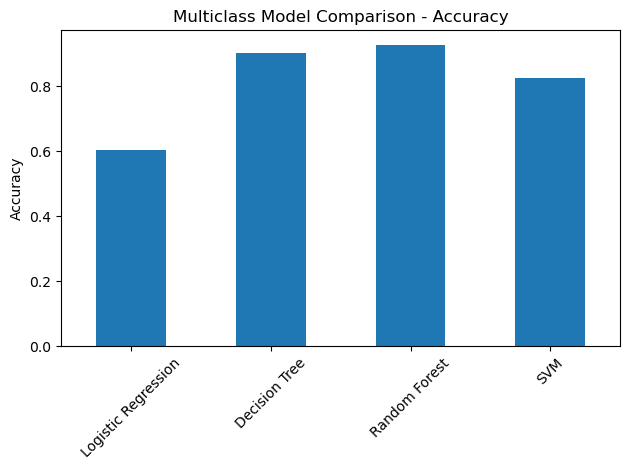

In [135]:
import matplotlib.pyplot as plt

plt.figure()
comparison_df["accuracy"].plot(kind="bar")
plt.title("Multiclass Model Comparison - Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Macro F1 Comparison

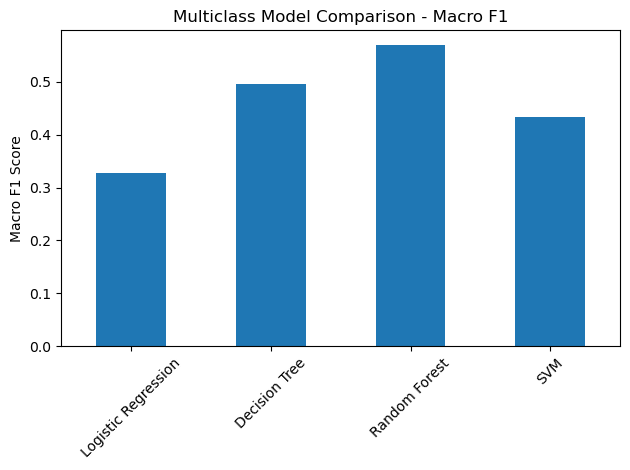

In [136]:
plt.figure()
comparison_df["macro_f1"].plot(kind="bar")
plt.title("Multiclass Model Comparison - Macro F1")
plt.ylabel("Macro F1 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Weighted F1 Comparison

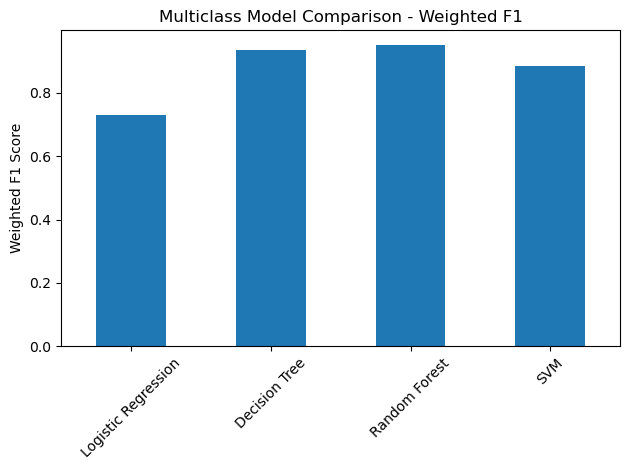

In [137]:
plt.figure()
comparison_df["weighted_f1"].plot(kind="bar")
plt.title("Multiclass Model Comparison - Weighted F1")
plt.ylabel("Weighted F1 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Multiclass ROC Curve

In [138]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities
rf_probs = rf_m.predict_proba(Xm_test)

# Binarize labels
classes = np.unique(ym_test)
ym_test_bin = label_binarize(ym_test, classes=classes)

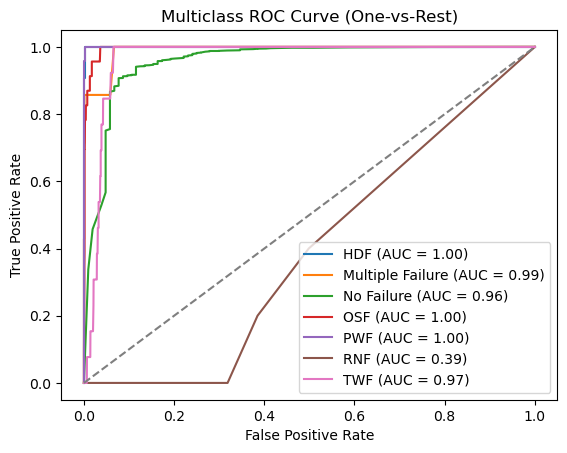

In [139]:
plt.figure()

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(ym_test_bin[:, i], rf_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

# Multiclass Confusion Matrix Heatmap

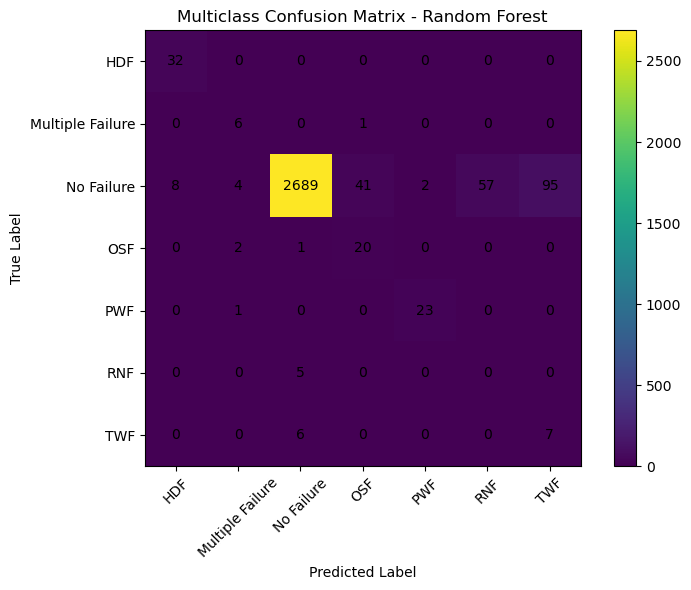

In [140]:
from sklearn.metrics import confusion_matrix

cm_multi = confusion_matrix(ym_test, rf_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm_multi)
plt.title("Multiclass Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm_multi.shape[0]):
    for j in range(cm_multi.shape[1]):
        plt.text(j, i, cm_multi[i, j],
                 ha="center", va="center")

plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

plt.tight_layout()
plt.show()

# Best Model

In [141]:
best_model = comparison_df["macro_f1"].idxmax()
print("Best Multiclass Model based on Macro F1:", best_model)

Best Multiclass Model based on Macro F1: Random Forest


In [142]:
best_model = comparison_df["weighted_f1"].idxmax()
print("Best Multiclass Model based on Weighted F1:", best_model)

Best Multiclass Model based on Weighted F1: Random Forest


In [143]:
best_model = comparison_df["macro_f1"].idxmax()
best_score = comparison_df["macro_f1"].max()

print(f"Best Multiclass Model: {best_model}")
print(f"Macro F1 Score: {best_score:.4f}")

Best Multiclass Model: Random Forest
Macro F1 Score: 0.5687
